### uMux Modeling Code

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from uMux_modeling.include.uMux_model import *

# --- Physical Constants ---
PHI_0 = 2.067e-15        # Flux quantum
M_IN = 250e-12           # TES-to-SQUID Mutual Inductance (250 pH)

# --- Resonator & SQUID Parameters ---
f_center = 5.0e9         # 5 GHz probe frequency
df_max = 100e3           # 100 kHz peak-to-peak SQUID swing
Q_tot = 50000            # Total Quality Factor
Q_c = 60000              # Coupling Quality Factor

# --- DAQ & Ramp Parameters ---
fs = 2.4e6               # 2.4 MHz sample rate
t_duration = 0.002       # 2 ms simulation time
f_ramp = 400e3          # 40 kHz flux ramp frequency
n_phi0 = 4              # Number of Phi_0 to sweep per ramp cycle

I_C = 1.0e-6        # Critical current (1 uA)
L_LOOP = 50e-12     # SQUID loop inductance (50 pH)
M_SQ = 20e-12       # Mutual inductance to resonator (20 pH)
L_RES = 2e-9        # Resonator inductance (2 nH)
C_RES = 0.5e-12     # Resonator capacitance (0.5 pF)

ModuleNotFoundError: No module named 'uMux_modeling.include.uMux_model'

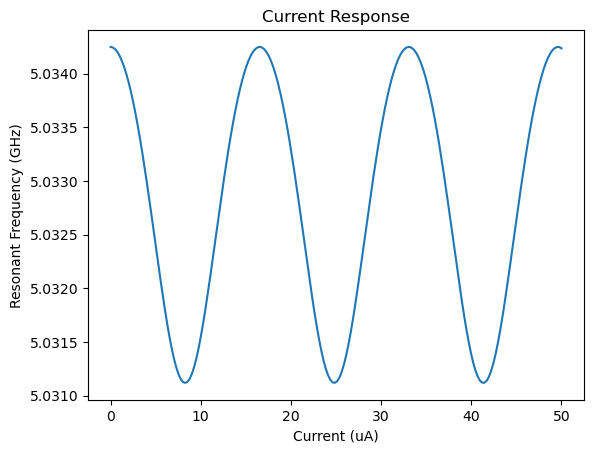

In [ ]:
I_array = np.linspace(0,50e-6,200)

fr_array = fr(flux_SQ(I_array), I_C, L_LOOP, L_RES, M_SQ, C_RES)

plt.plot(I_array*1e6,fr_array*1e-9)
plt.xlabel("Current (uA)")
plt.ylabel("Resonant Frequency (GHz)")
plt.title("Current Response")
plt.show()


### Flux Ramp Biasing

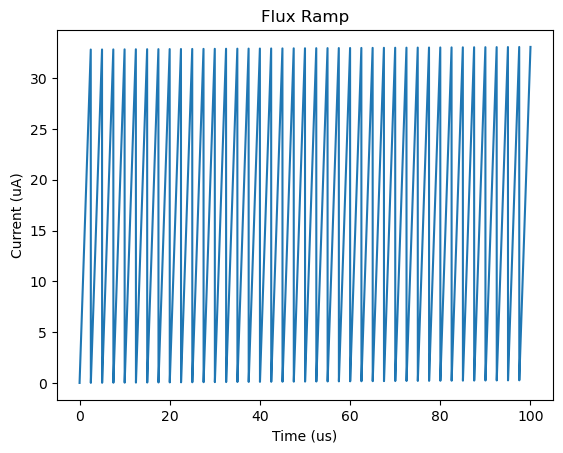

In [ ]:


t_array = np.linspace(0,100e-6,5000)

flux_ramp = generate_flux_ramp(t_array,f_ramp,n_phi0)
I_ramp = flux_ramp/M_IN

plt.plot(t_array*1e6,I_ramp*1e6)
plt.title("Flux Ramp")
plt.xlabel("Time (us)")
plt.ylabel("Current (uA)")
plt.show()

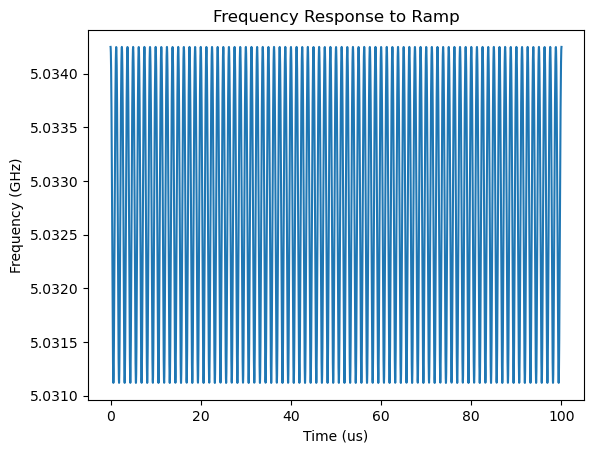

In [ ]:
fr_ramp_array = fr(flux_ramp, I_C, L_LOOP, L_RES, M_SQ, C_RES)

plt.plot(t_array*1e6,fr_ramp_array*1e-9)
plt.title("Frequency Response to Ramp")
plt.xlabel("Time (us)")
plt.ylabel("Frequency (GHz)")
plt.show()

In [ ]:
def generate_tes_pulse(t, t0, peak_amplitude, tau):
    """
    Creates a current pulse with an instantaneous rise and exponential decay.
    """
    pulse = np.zeros_like(t)
    mask = t >= t0
    pulse[mask] = peak_amplitude * np.exp(-(t[mask] - t0) / tau)
    return pulse

I_peak = 5e-9       # 5 micro-amps
t_onset = 20e-6     # Pulse starts at 20us
tau_decay = 150e-6   # 15us decay constant

I_tes = generate_tes_pulse(t_array, t_onset, I_peak, tau_decay)

plt.plot(t_array*1e6,I_tes*1e6)
plt.xlabel("Time (us)")
plt.title("TES Pulse")
plt.ylabel("Current (uA)")

NameError: name 't_array' is not defined

In [ ]:
I_total = I_tes + I_ramp
flux_total = flux_SQ(I_total)
fr_pulse_array = fr(flux_total, I_C, L_LOOP, L_RES, M_SQ, C_RES)

fr_signal = fr_pulse_array-fr_ramp_array

fr_diff = fr_pulse_array - fr_ramp_array 
df_dphi = np.gradient(fr_ramp_array, flux_ramp)

samples_per_ramp =  int(len(t_array) / (t_array[-1] * f_ramp))
num_ramps = len(t_array) // samples_per_ramp

I_final = []
t_final = []

for i in range(num_ramps):
    start = i * samples_per_ramp
    end = (i + 1) * samples_per_ramp
    
    sig_chunk = fr_diff[start:end]
    slope_chunk = df_dphi[start:end]
    
    numerator = np.sum(sig_chunk * slope_chunk)
    denominator = np.sum((slope_chunk**2) * M_IN)
    
    I_final.append(numerator / denominator)
    t_final.append(np.mean(t_array[start:end]))

plt.plot(np.array(t_final)*1e6, np.array(I_final)*1e6, marker='o')
plt.plot(t_array*1e6,I_tes*1e6)
plt.title("Final Demodulated TES Pulse")
plt.ylabel("Current (uA)")
plt.xlabel("Time (us)")

NameError: name 'I_tes' is not defined